##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [3]:
!pip install -q tensorflow tensorflow-hub pillow matplotlib opencv-python

In [4]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
import requests
import cv2

from PIL import Image
from io import BytesIO

In [5]:
model_url = "https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2/TensorFlow2/1024x1024/1"

model = hub.load(model_url)

print("Model loaded successfully")

Model loaded successfully


In [6]:
COCO_CLASSES = [
    "background", "person", "bicycle", "car", "motorcycle", "airplane", "bus",
    "train", "truck", "boat", "traffic light", "fire hydrant", "stop sign",
    "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag",
    "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite",
    "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket",
    "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana",
    "apple", "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed", "dining table",
    "toilet", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock",
    "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

In [15]:
from urllib.request import Request, urlopen
from PIL import Image
import numpy as np

def load_image_from_url(url):

    req = Request(
        url,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    image = np.array(
        Image.open(
            urlopen(req)
        ).convert("RGB")
    )

    return image

In [16]:
IMAGE_URLS = [
    "https://images.unsplash.com/photo-1502877338535-766e1452684a",
    "https://images.unsplash.com/photo-1544005313-94ddf0286df2",
    "https://images.unsplash.com/photo-1517849845537-4d257902454a",
    "https://images.unsplash.com/photo-1492724441997-5dc865305da7",
    "https://images.unsplash.com/photo-1519710164239-da123dc03ef4"
]

In [17]:
images = [load_image_from_url(url) for url in IMAGE_URLS]

print("Number of images:", len(images))
print("First image shape:", images[0].shape)

Number of images: 5
First image shape: (3901, 5859, 3)


In [33]:
def run_inference(image):
    input_tensor = tf.convert_to_tensor(image)
    input_tensor = input_tensor[tf.newaxis, ...]

    outputs = model(input_tensor)

    return outputs

In [34]:
outputs_list = []

for image in images:
    outputs = run_inference(image)
    outputs_list.append(outputs)

print("Inference completed for", len(outputs_list), "images")

Inference completed for 5 images


In [46]:
def extract_predictions(result, threshold=0.5):

    boxes = result["detection_boxes"][0].numpy()
    classes = result["detection_classes"][0].numpy().astype(int)
    scores = result["detection_scores"][0].numpy()
    masks = result["detection_masks"][0].numpy()

    valid_indices = scores >= threshold

    boxes = boxes[valid_indices]
    classes = classes[valid_indices]
    scores = scores[valid_indices]
    masks = masks[valid_indices]

    return boxes, classes, scores, masks

In [62]:
def visualize_predictions(
    image,
    boxes,
    classes,
    scores,
    masks,
    alpha=0.4
):

    output = image.copy().astype(np.uint8)

    h, w, _ = image.shape

    for i in range(len(scores)):

        ymin, xmin, ymax, xmax = boxes[i]

        x1 = int(xmin * w)
        y1 = int(ymin * h)
        x2 = int(xmax * w)
        y2 = int(ymax * h)

        class_name = COCO_CLASSES[classes[i]]

        score_text = f"{class_name}: {scores[i]:.2f}"

        color = tuple(np.random.randint(0, 255, size=3).tolist())

        # Draw box
        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            color,
            2
        )

        # Draw label background
        cv2.rectangle(
            output,
            (x1, max(0, y1 - 25)),
            (x1 + 180, y1),
            color,
            -1
        )

        cv2.putText(
            output,
            score_text,
            (x1 + 5, y1 - 7),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2
        )

        # Segmentation mask
        mask = masks[i]

        mask = cv2.resize(mask, (w, h))

        mask = mask > 0.5

        colored_mask = np.zeros_like(output, dtype=np.uint8)

        colored_mask[mask] = color

        output = cv2.addWeighted(
            output,
            1.0,
            colored_mask,
            alpha,
            0
        )

    return output

Image 1
Detected objects:
 - car (1.00)


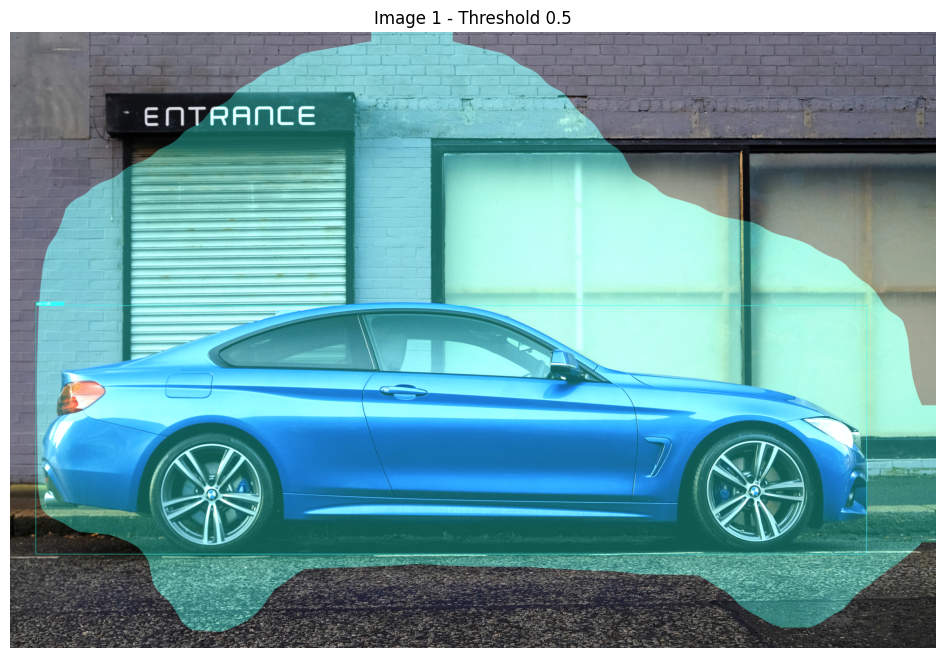

Image 2
Detected objects:
 - person (1.00)


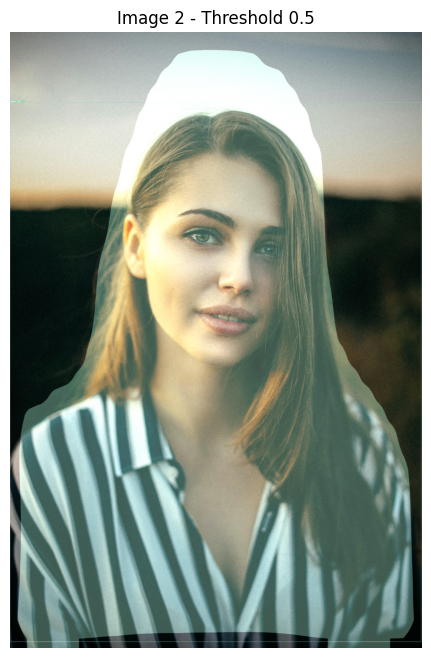

Image 3
Detected objects:
 - horse (1.00)


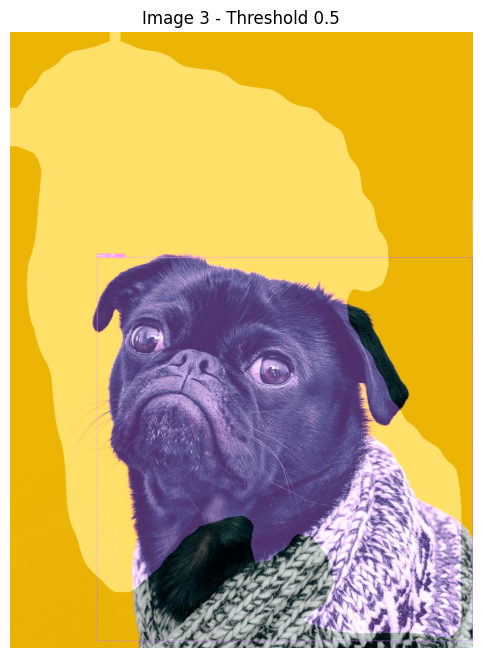

Image 4
Detected objects:
 - banana (1.00)
 - vase (1.00)
 - sink (1.00)
 - book (0.92)
 - book (0.82)
 - scissors (0.80)
 - refrigerator (0.73)
 - scissors (0.61)


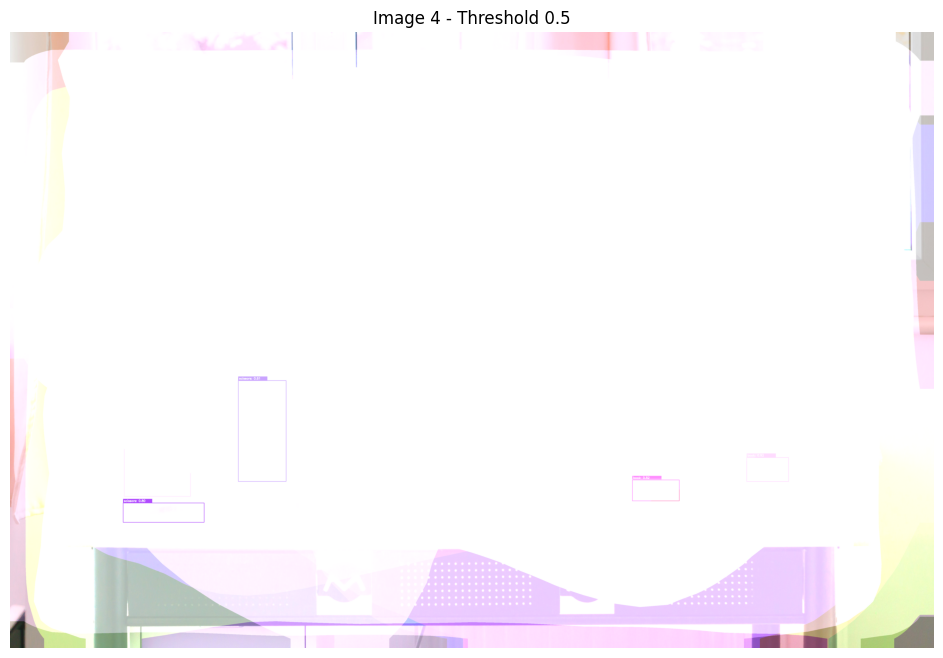

IndexError: list index out of range

In [65]:
results_threshold_05 = []

for i, image in enumerate(images):

    # Extract predictions first
    boxes, classes, scores, masks = extract_predictions(
        outputs_list[i],
        threshold=0.5
    )

    # Visualization
    vis = visualize_predictions(
        image,
        boxes,
        classes,
        scores,
        masks
    )

    print("Image", i + 1)

    print("Detected objects:")

    for c, s in zip(classes, scores):

        print(
            f" - {COCO_CLASSES[c]} ({s:.2f})"
        )

    # Show image
    plt.figure(figsize=(12, 8))

    plt.imshow(vis)

    plt.title(f"Image {i+1} - Threshold 0.5")

    plt.axis("off")

    plt.show()

    results_threshold_05.append({
        "classes": classes,
        "scores": scores
    })